Если панд нет - ставим

In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Импортируем библиотеку

In [2]:
import pandas as pd

### 1) Загрузка и первичная обработка данных:

- Загрузить датасет с помощью pandas. 
- Вывести первые и последние строки таблицы. 

In [3]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import kagglehub
kagglehub.login()
from kagglehub import KaggleDatasetAdapter

In [7]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "ashyou09/global-deforestation-and-afforestation-2000-2025",
    "global_deforestation_2000_2025.csv",
)
df.to_csv('global_deforestation_2000_2025.csv')#, index=False)
df

,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes,Primary_Driver_of_Change
0,Brazil,2000,5468301,8515767,64.21,0.00,0.00,87197411954,Initial State
1,Brazil,2001,5439758,8515767,63.88,1.07,0.55,86742262748,NaN
2,Brazil,2002,5408757,8515767,63.51,1.43,0.86,86247929409,NaN
3,Brazil,2003,5326870,8515767,62.55,1.56,0.05,84942146407,NaN
4,Brazil,2004,5280984,8515767,62.01,0.94,0.08,84210458080,NaN
...,...,...,...,...,...,...,...,...,...
5715,Country_Gen_219,2021,15900,35671,44.58,0.26,0.94,273847011,NaN
5716,Country_Gen_219,2022,15732,35671,44.11,1.18,0.13,270951966,NaN
5717,Country_Gen_219,2023,15744,35671,44.14,0.52,0.60,271153849,NaN
5718,Country_Gen_219,2024,15857,35671,44.46,0.21,0.93,273101866,NaN


- размер датасета

In [9]:
print(f"Размер датасета (строки, столбцы): {df.shape}")
print("\nТипы данных и общая информация:")
df.info()

Размер датасета (строки, столбцы): (5720, 10)

Типы данных и общая информация:
<class 'pandas.DataFrame'>
RangeIndex: 5720 entries, 0 to 5719
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 5720 non-null   int64  
 1   Country                    5720 non-null   str    
 2   Year                       5720 non-null   int64  
 3   Forest_Area_km2            5720 non-null   int64  
 4   Land_Area_km2              5720 non-null   int64  
 5   Forest_Cover_Pct           5720 non-null   float64
 6   Annual_Deforestation_Rate  5720 non-null   float64
 7   Annual_Afforestation_Rate  5720 non-null   float64
 8   Total_Carbon_Stock_Tonnes  5720 non-null   int64  
 9   Primary_Driver_of_Change   1344 non-null   str    
dtypes: float64(3), int64(5), str(2)
memory usage: 447.0 KB


### 2) Очистка данных 

- Найти пропущенные значения

In [10]:
df.isnull().sum()

Unnamed: 0                      0
Country                         0
Year                            0
Forest_Area_km2                 0
Land_Area_km2                   0
Forest_Cover_Pct                0
Annual_Deforestation_Rate       0
Annual_Afforestation_Rate       0
Total_Carbon_Stock_Tonnes       0
Primary_Driver_of_Change     4376
dtype: int64

всё хорошо, надо испортить

для rng понадобится numpy

In [11]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import numpy as np

In [13]:
np.random.seed(42)
prop_missing = 0.05 
mask = np.random.rand(len(df)) < prop_missing
df.loc[mask, 'Annual_Deforestation_Rate'] = np.nan

In [14]:
df.isnull().sum()

Unnamed: 0                      0
Country                         0
Year                            0
Forest_Area_km2                 0
Land_Area_km2                   0
Forest_Cover_Pct                0
Annual_Deforestation_Rate     281
Annual_Afforestation_Rate       0
Total_Carbon_Stock_Tonnes       0
Primary_Driver_of_Change     4376
dtype: int64

ну теперь другое дело - чиним

Считаю, что удалять данные нецелесообразно, т.к. в таком случае мы теряем значения за определённые года для стран. Заполним пропуски медианными значениями, они менее чувствительны к скачкам значений.

In [15]:
median_rate = df['Annual_Deforestation_Rate'].median()
df['Annual_Deforestation_Rate'] = df['Annual_Deforestation_Rate'].fillna(median_rate)
df.isnull().sum()

Unnamed: 0                      0
Country                         0
Year                            0
Forest_Area_km2                 0
Land_Area_km2                   0
Forest_Cover_Pct                0
Annual_Deforestation_Rate       0
Annual_Afforestation_Rate       0
Total_Carbon_Stock_Tonnes       0
Primary_Driver_of_Change     4376
dtype: int64

Заменяю None на Unknown на всякий случай.

In [16]:
df['Primary_Driver_of_Change'] = df['Primary_Driver_of_Change'].replace('None', 'Unknown')

In [17]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

У нас дубликатов нет, но всё равно удалим.

In [18]:
df = df.drop_duplicates()

С данными вроде всё ок, можем разве что string перевести в category, уменьшить битность численных.

In [19]:
df['Country'] = df['Country'].astype('category')
df['Primary_Driver_of_Change'] = df['Primary_Driver_of_Change'].astype('category')

### 3) Базовый анализ данных

- Рассчитать основные статистические показатели по столбцам:
    - Среднее значение - mean
    - Медиану - 50%
    - Минимум и максимум - min и max
    - Стандартное отклонение - std

In [20]:
display(df.describe())

,Unnamed: 0,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes
count,5720.000000,5720.000000,5.720000e+03,5.720000e+03,5720.000000,5720.000000,5720.000000,5.720000e+03
mean,2859.500000,2012.500000,2.488515e+05,6.130764e+05,37.767631,0.637227,0.530743,3.391204e+09
std,1651.366101,7.500656,8.085413e+05,1.811260e+06,14.531141,0.509971,0.309129,1.287569e+10
min,0.000000,2000.000000,0.000000e+00,0.000000e+00,0.520000,0.000000,0.000000,2.319000e+03
25%,1429.750000,2006.000000,6.947500e+03,2.129450e+04,27.127500,0.190000,0.280000,7.886271e+07
50%,2859.500000,2012.500000,3.247850e+04,9.276700e+04,40.000000,0.540000,0.540000,3.401356e+08
75%,4289.250000,2019.000000,1.581042e+05,4.481238e+05,47.870000,1.030000,0.790000,1.737695e+09
max,5719.000000,2025.000000,8.110534e+06,1.709824e+07,79.970000,3.360000,1.200000,1.587906e+11


- Рассчитать баланс классов (по причинам вырубки)

In [21]:
df['Primary_Driver_of_Change'].value_counts()

Primary_Driver_of_Change
Initial State              220
Infrastructure             156
Fire                       146
Small-scale Agriculture    144
Urbanization               143
Commercial Agriculture     139
Logging                    137
Mining                     133
Energy                     126
Name: count, dtype: int64

- Построить группировку по одному или нескольким признакам
- Определить: 
    - Наиболее часто встречающиеся категории; 
    - Топ-5 значений по выбранному критерию

In [22]:
top_drivers = df.groupby('Primary_Driver_of_Change')['Annual_Deforestation_Rate'].mean().sort_values(ascending=False)
print("Средний темп вырубки в зависимости от причины:")
top_drivers.head(5)

Средний темп вырубки в зависимости от причины:


Primary_Driver_of_Change
Fire                       1.793356
Commercial Agriculture     0.934173
Mining                     0.748120
Small-scale Agriculture    0.639097
Infrastructure             0.630641
Name: Annual_Deforestation_Rate, dtype: float64

### 4) Сформулировать вывод о наборе данных:

- Наиболее важные столбцы:

`Country` (позволяет оценивать региональные тренды), `Year` (динамика во времени), `Forest_Cover_Pct` и `Annual_Deforestation_Rate` (отражают саму суть проблемы), а также `Primary_Driver_of_Change` (показывает причину).

Так же `Annual_Deforestation_Rate` и `Annual_Afforestation_Rate ` являются относительными значениями, что полезно для сравнений значений различных категорий.

- Какие закономерности можно выявить без применения методов машинного 
обучения?

Уже на этапе группировки можно заметить, что страны с высокими темпами коммерческого сельского хозяйства (Commercial Agriculture) или лесных пожаров (Fire) демонстрируют наиболее сильное снижение запасов углерода.

### Визуализация данных: 

библиотеки для визуализации, то-сё

In [23]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import matplotlib.pyplot as plt

Обновим данные до изначальных

In [25]:
df = pd.read_csv('global_deforestation_2000_2025.csv')

#### 1) Построить гистограммы (распределение числового признака) для двух числовых столбцов.

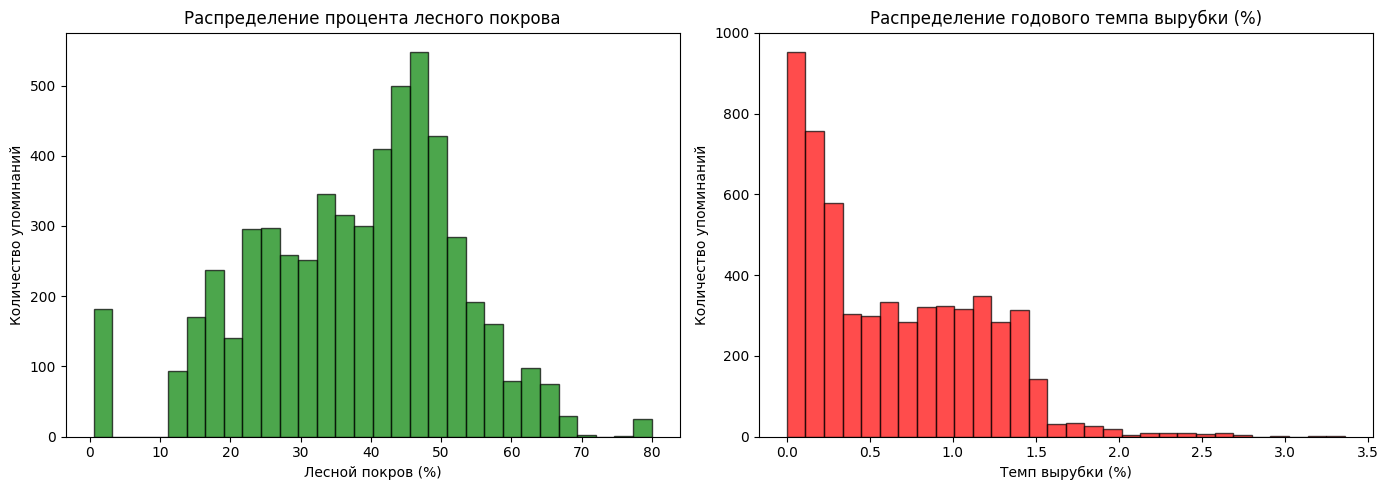

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['Forest_Cover_Pct'].dropna(), bins=30, color='green', edgecolor='black', alpha=0.7)
ax[0].set_title('Распределение процента лесного покрова')
ax[0].set_xlabel('Лесной покров (%)')
ax[0].set_ylabel('Количество упоминаний')

ax[1].hist(df['Annual_Deforestation_Rate'].dropna(), bins=30, color='red', edgecolor='black', alpha=0.7)
ax[1].set_title('Распределение годового темпа вырубки (%)')
ax[1].set_xlabel('Темп вырубки (%)')
ax[1].set_ylabel('Количество упоминаний')

plt.tight_layout()
plt.show()

- Процент лесного покрова: Распределение показывает, что в датасете присутствуют как страны с малым количеством лесов, так и с большим. Превалируют страны приближенные к "среднему" количеству леса.

- Темп вырубки: График сильно смещен влево. Это означает, что для большинства стран характерен относительно невысокий базовый темп вырубки (основная масса данных сгруппирована около нуля).

#### 2) Построить столбчатую диаграмму для категориального признака

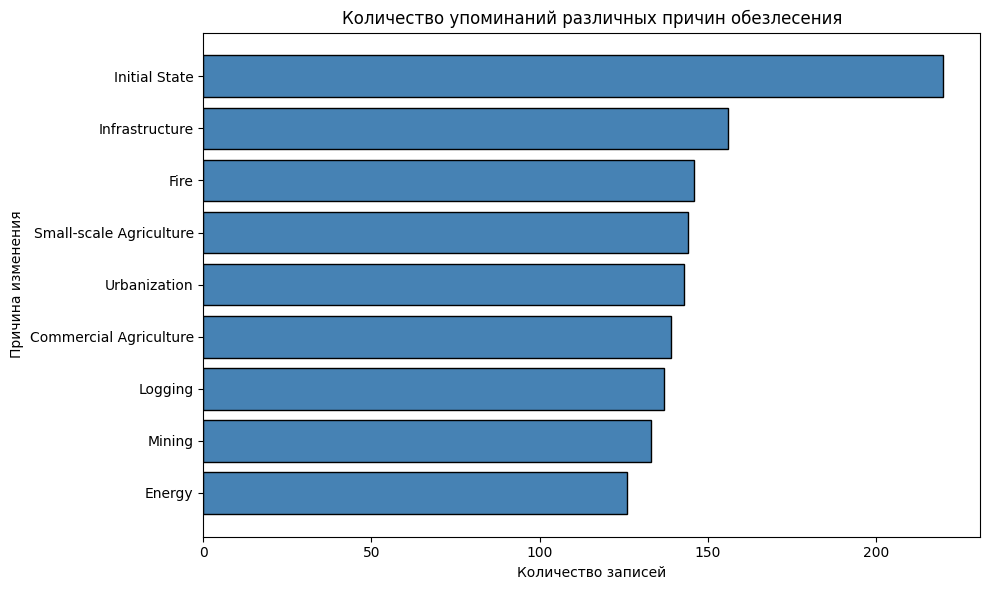

In [27]:
plt.figure(figsize=(10, 6))

driver_counts_all = df['Primary_Driver_of_Change'].value_counts().sort_values(ascending=True)

plt.barh(driver_counts_all.index.astype(str), driver_counts_all.values, color='steelblue', edgecolor='black')
plt.title('Количество упоминаний различных причин обезлесения')
plt.xlabel('Количество записей')
plt.ylabel('Причина изменения')
plt.tight_layout()
plt.show()

- Классы причин изменения лесного покрова распределены практически поровну.

#### 3) Построить круговую диаграмму для категориального признака.

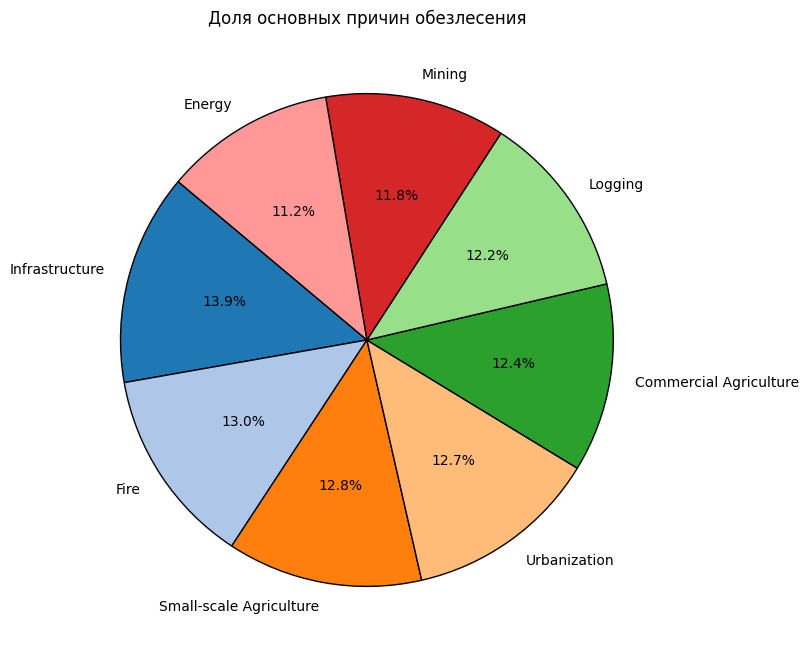

In [28]:
# Исключаем "Initial State", чтобы оценить только реальные причины
driver_counts_pie = df[df['Primary_Driver_of_Change'] != 'Initial State']['Primary_Driver_of_Change'].value_counts()

plt.figure(figsize=(8, 8))
# Берем цвета из стандартной палитры
colors = plt.cm.tab20.colors[:len(driver_counts_pie)]
plt.pie(driver_counts_pie, labels=driver_counts_pie.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Доля основных причин обезлесения')
plt.show()

- В данном наборе данных причины распределены практически равномерно. Ни один из факторов не является доминирующим — каждая причина (от инфраструктурных проектов до пожаров и сельского хозяйства) занимает долю в узком диапазоне от 11% до 14%.

#### 4) Построить линейный график для любого признака => отобразить динамику.

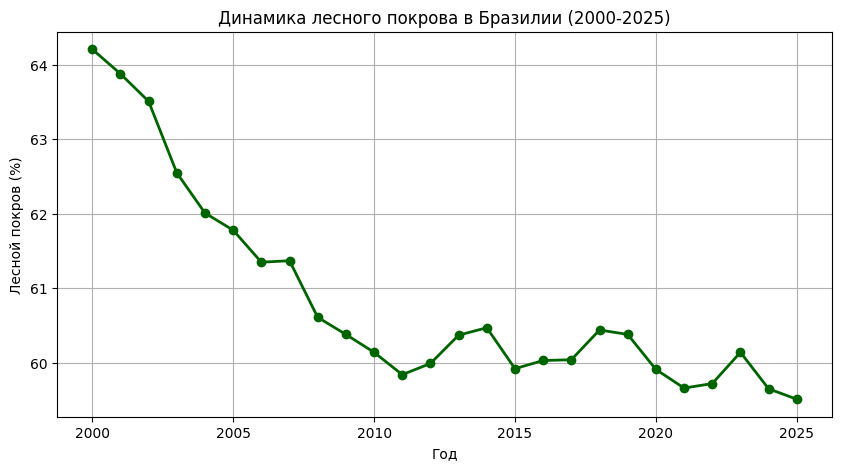

In [29]:
brazil_data = df[df['Country'] == 'Brazil'].sort_values('Year')

plt.figure(figsize=(10, 5))
plt.plot(brazil_data['Year'], brazil_data['Forest_Cover_Pct'], marker='o', color='darkgreen', linestyle='-', linewidth=2)
plt.title('Динамика лесного покрова в Бразилии (2000-2025)')
plt.xlabel('Год')
plt.ylabel('Лесной покров (%)')
plt.grid(True)
plt.show()

- Линия демонстрирует убывающий тренд. Доля лесного покрова Бразилии с 2000 по 2025 год падает. Однако после 2010 года скорость убывания уменьшается почти до баланса вырубки и восстановления согласно набору данных.

#### 5) Построить сравнительную столбчатую диаграмму для нескольких признаков 
(признаки должны быть измеримы по одной шкале, например: оценки, 
деньги в одной валюте и др).

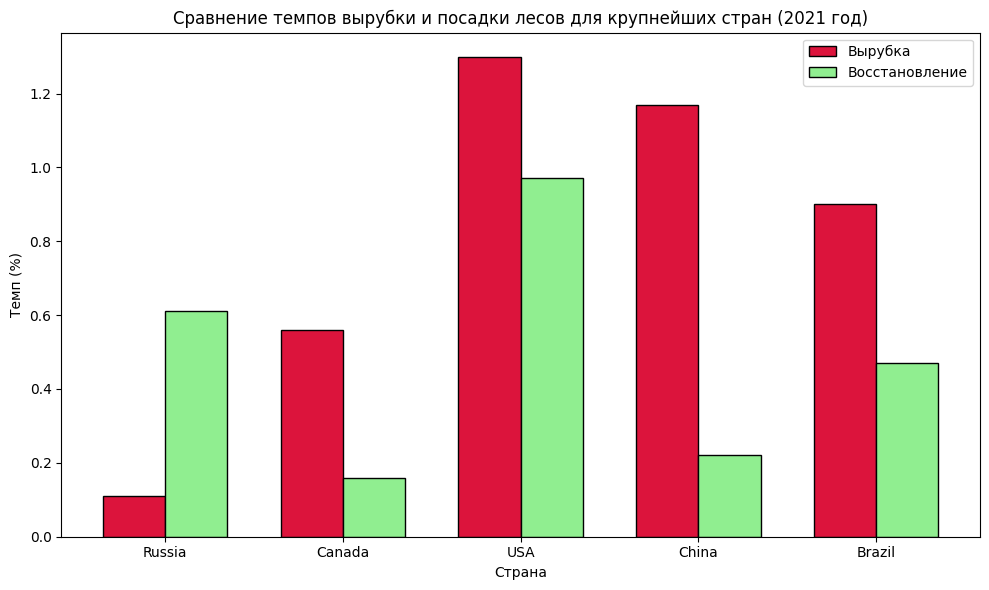

In [30]:
# Выбираем 5 крупнейших по площади стран в 2021 году
comp_data = df[df['Year'] == 2021].sort_values('Land_Area_km2', ascending=False).head(5)

countries = comp_data['Country'].astype(str)
deforestation = comp_data['Annual_Deforestation_Rate']
afforestation = comp_data['Annual_Afforestation_Rate']

x = np.arange(len(countries)) 
width = 0.35  

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, deforestation, width, label='Вырубка', color='crimson', edgecolor='black')
plt.bar(x + width/2, afforestation, width, label='Восстановление', color='lightgreen', edgecolor='black')

# Настраиваем оформление
plt.title('Сравнение темпов вырубки и посадки лесов для крупнейших стран (2021 год)')
plt.xlabel('Страна')
plt.ylabel('Темп (%)')

plt.xticks(x, countries, rotation=0)

plt.legend()
plt.tight_layout()
plt.show()

- В в представленной выборке крупнейших стран темпы вырубки лесов в большинстве представленных стран превышали темпы их восстановления. Это указывает на то, что за этот период чистая площадь лесного покрова в этих регионах сократилась.